In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_and_process_results,
    match_datasets,
    matching_precision_recall,
    get_filenames_in_directory,
    fit_temperature,
    apply_temperature,
    fit_temperature_from_probs,
    apply_temperature_from_probs,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

### Ground Truth Dataset

In [2]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/pond/directory.json"), "r") as f:
    paper_info = json.load(f)

'''
paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]
'''

paper_subset = [
    'classification_trees',
    'physical-chemical_influences',
    'habitat_characteristics',
    'physical_and_chemical_limnological',
    'prairie_wetland',
    'macroinvertebrate_size',
    'relationships_between_fish',
    'net_heterotrophy',
    'impact_of_macrophytes',
    'environmental_conditions',
]


paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()

ground_truth_df = pd.read_csv("../data/pond/pond_data_corrected.csv", encoding_errors='ignore', index_col = 0)
ground_truth_df = ground_truth_df.loc[ground_truth_df.title.isin(registered_titles)]
ground_truth_df = ground_truth_df.reset_index(drop=True)

In [3]:
registered_titles

['classification trees as a tool for predicting cyanobacterial blooms',
 'environmental conditions and macrophytes of karst ponds',
 'habitat characteristics and odonate diversity in mountain ponds of central italy',
 'impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration',
 'macroinvertebrate size spectra of mediterranean ponds with differing hydroperiod length',
 'net heterotrophy in small danish lakes: a widespread feature over gradients in trophic status and land cover',
 'physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic',
 'physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa',
 'prairie wetland communities recover at different rates following hydrological restoration',
 'relationships between fish feeding guild and trophic structure in english lowland shallow lakes subject to anth

In [4]:
ground_truth_df

,author,title,name,location,ecosystem,date,state,attribute,value
0,peretyatko; anatoly; teissier; samuel; de back...,classification trees as a tool for predicting ...,vkn1,belgium,pond,NaN,NaN,chla,30.50
1,peretyatko; anatoly; teissier; samuel; de back...,classification trees as a tool for predicting ...,vkn2,belgium,pond,NaN,NaN,chla,30.70
2,peretyatko; anatoly; teissier; samuel; de back...,classification trees as a tool for predicting ...,sbsk,belgium,pond,NaN,NaN,chla,39.90
3,peretyatko; anatoly; teissier; samuel; de back...,classification trees as a tool for predicting ...,sclm,belgium,pond,NaN,NaN,chla,169.10
4,peretyatko; anatoly; teissier; samuel; de back...,classification trees as a tool for predicting ...,silx,belgium,pond,NaN,NaN,chla,21.90
...,...,...,...,...,...,...,...,...,...
1296,zambrano,relationships between fish feeding guild and t...,saham,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,0.00
1297,zambrano,relationships between fish feeding guild and t...,pedham,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,3.80
1298,zambrano,relationships between fish feeding guild and t...,lowes,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,1.10
1299,zambrano,relationships between fish feeding guild and t...,lily,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,0.00


### Data from Intermediate Pipeline steps

In [4]:
main_directory = "../data/pond"
pdf_directory = os.path.join(main_directory, "pdfs")
ocr_directory = os.path.join(main_directory, "ocr_output_cleaned_gpt_5_mini")
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)

text_files = get_filenames_in_directory(ocr_directory, ignore = [".DS_Store", ".gitkeep"])
text_files.sort()

titles = [paper_info[file.replace('.txt', '')]['title'] for file in text_files]

**1. Extracted Entities**

In [6]:
extracted_entity_data_path = "../data/experiments/2026_03_04/pond_entities.json"

with open(extracted_entity_data_path, "r") as f:
    extracted_entity_data = json.load(f)

extracted_entity_data = [e | {'title': titles[e['document_id']]} for e in extracted_entity_data]

entity_strict_fields = ["title"]
entity_fuzzy_fields = ["name", "location", "ecosystem"]

extracted_entity_df = pd.DataFrame(extracted_entity_data)
extracted_entity_df = extracted_entity_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
extracted_entity_df = extracted_entity_df.reset_index(drop=True)

ground_truth_entity_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields + entity_fuzzy_fields)
ground_truth_entity_df = ground_truth_entity_df.reset_index(drop=True)

In [7]:
entity_matching, entity_recall, entity_precision = matching_precision_recall(
    ground_truth_entity_df,
    extracted_entity_df,
    strict_matching = {'title': 'title'},
    fuzzy_matching = {'name':'name', 'location':'location', 'ecosystem': 'ecosystem'},
    fuzzy_threshold = 0.5
)

In [8]:
entity_recall

0.7953410981697171

In [9]:
entity_precision

0.4681684622918707

**2. Detected Attributes**

In [10]:
extracted_attribute_data_path = "../data/experiments/2026_03_04/pond_attributes.json"

with open(extracted_attribute_data_path, "r") as f:
    extracted_attribute_data = json.load(f)

extracted_attribute_dataset = []
for doc_id, attr_dict in extracted_attribute_data.items():
    for attr in attr_dict.keys():
        extracted_attribute_dataset.append({'title': titles[int(doc_id)], 'attribute': attr})

entity_strict_fields = ["title", "attribute"]

extracted_attribute_df = pd.DataFrame(extracted_attribute_dataset)
extracted_attribute_df = extracted_attribute_df.drop_duplicates(subset = entity_strict_fields)

ground_truth_attribute_df = ground_truth_df.drop_duplicates(subset = entity_strict_fields)

In [11]:
attribute_matching, attribute_recall, attribute_precision = matching_precision_recall(
    ground_truth_attribute_df,
    extracted_attribute_df,
    strict_matching = {'title':'title', 'attribute':'attribute'},
    fuzzy_matching = {},
    fuzzy_threshold = 0.0
)

In [12]:
attribute_recall

0.9536231884057971

In [13]:
attribute_precision

0.6388349514563106

### Full, Extracted Dataset

In [88]:
# ---------------------------------
# Load experiment results
# ---------------------------------

#experiment_data_path = "../data/experiments/2026_03_04/pond_judged_combined.json"
#experiment_data_path = "../data/experiments/pond_ten/extraction/gpt-oss-120b/2026_04_14/final.json"
#experiment_data_path = "../data/experiments/pond_ten/ablations/ablation6/gpt-oss-120b/2026_04_14/final.json"

experiment_data_path = "../data/experiments/pond_ten/judge/gpt-oss-120b/2026_04_14/combined/combined.json"
experiment_data_path = "../data/experiments/pond_ten/ablations/ablation6/gpt-oss-120b/2026_04_14/judge/combined/combined.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1.0, "fraction": 100.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)

extracted_df = extracted_df.loc[extracted_df.title.isin(registered_titles)]
extracted_df.reset_index(drop=True, inplace=True)

In [89]:
# Hallucination Rate:
1 - extracted_df['judgement_combined'].sum() / len(extracted_df)

np.float64(0.20562939796716184)

### Match Extractions to Ground Truth

In [69]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "title": "title", # name in the ground truth dataset : name in the extracted dataset
    "attribute": "attribute",
    "value": "processed_value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "name": "name",
    "location": "location",
    "ecosystem": "ecosystem",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, matching_recall, matching_precision = matching_precision_recall(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching,
    fuzzy_threshold = 1/4
)

print(f"Recall: {matching_recall:.4f}")
print(f"Precision: {matching_precision:.4f}")

Recall: 0.6879
Precision: 0.6233


### Debugging:

In [12]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [78]:
unmatched_gt_df.title.value_counts().head(10)

title
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa                                                               96
environmental conditions and macrophytes of karst ponds                                                                                                                            84
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            78
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             56
biodiversity of constructed wetlands for wastewater treatment                       

In [68]:
unmatched_gt_df.title.value_counts().head(10)

title
environmental conditions and macrophytes of karst ponds                                                                                                                            81
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            77
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                                         74
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             63
relationships between fish feeding guild and trophic structure in english lowland sh

In [20]:
matched_gt_df.title.value_counts()

title
vegetation-environmental variable relationships in ponds of various origins along an altitudinal gradient                        43
distinct optical chemistry of dissolved organic matter in urban pond ecosystems                                                  29
productivity and depth regulate lake contributions to atmospheric methane                                                        19
lake morphometry moderates the relationship between water color and fish biomass in small boreal lakes                           16
sediment characteristics and accumulation rates in constructed ponds                                                             10
natural variability of carbon dioxide and net epilimnetic production in the surface waters of boreal lakes of different sizes     4
fish assemblages in floodplain lakes in a neotropical river during the wet season (magdalena river; colombia)                     3
conservation of pond systems: a case study of intractability; brown mo

In [85]:
title = "biodiversity of constructed wetlands for wastewater treatment"
gt_title_df = ground_truth_df.loc[ground_truth_df.title == title]
unmatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = extracted_df.loc[extracted_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

### Judgement

In [70]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] | matching_status
extracted_df['matching_status'] = matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [71]:
extracted_df['validation'].sum() / len(extracted_df)

np.float64(0.8857938718662952)

In [72]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

'''
prediction_dict = {
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
    "llama": extracted_df['judgement_llama'],
}
'''

prediction_dict = {
    "gpt-oss-120b": extracted_df['judgement_gpt-oss-120b'],
    "llama-3.3-70b": extracted_df['judgement_llama-3.3-70b'],
    "qwen-2.5-72b": extracted_df['judgement_qwen-2.5-72b'],
    "llama-3.1-8b": extracted_df['judgement_llama-3.1-8b'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    recall = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  FPR:       {fpr:.4f}")
    print()

Model: gpt-oss-120b
  TP=969, FP=10, TN=154, FN=303
  Accuracy:  0.7820
  Precision: 0.9898
  Recall:    0.7618
  F1:        0.8610
  FPR:       0.0610

Model: llama-3.3-70b
  TP=1204, FP=72, TN=92, FN=68
  Accuracy:  0.9025
  Precision: 0.9436
  Recall:    0.9465
  F1:        0.9451
  FPR:       0.4390

Model: qwen-2.5-72b
  TP=1109, FP=8, TN=156, FN=163
  Accuracy:  0.8809
  Precision: 0.9928
  Recall:    0.8719
  F1:        0.9284
  FPR:       0.0488

Model: llama-3.1-8b
  TP=339, FP=14, TN=150, FN=933
  Accuracy:  0.3405
  Precision: 0.9603
  Recall:    0.2665
  F1:        0.4172
  FPR:       0.0854



### Baseline Calibration

In [73]:
# ── Publication style ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 300,
})

COLORS = {
    "llama": "#1b6ca8",
    "gpt":   "#c44e52",
    "diag":  "#333333",
}

In [74]:
# ── Compute calibration values ──
def compute_calibration(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_means = []
    bin_ses = []
    bin_counts = []
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        if b == n_bins - 1:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        bin_labels = labels[mask].astype(float)
        p = bin_labels.mean()
        n = len(bin_labels)
        bin_centers.append(probs[mask].mean())
        bin_means.append(p)
        bin_ses.append(np.sqrt(p * (1 - p) / n))
        bin_counts.append(n)
    return {
        "centers": np.array(bin_centers),
        "means": np.array(bin_means),
        "ses": np.array(bin_ses),
        "counts": bin_counts,
    }

In [75]:
# ── Llama baseline next token probability calibration ──
llama_p_true = extracted_df['judgement_p_true_llama-3.1-8b'].to_numpy()
cal_llama_baseline = compute_calibration(llama_p_true, labels)

logits_true = extracted_df['judgement_logit_p_true_llama-3.1-8b'].to_numpy()
logits_false = extracted_df['judgement_logit_p_false_llama-3.1-8b'].to_numpy()
best_t = fit_temperature(logits_true, logits_false, labels)
llama_p_true_temp, llama_p_false_temp = apply_temperature(logits_true, logits_false, best_t)
cal_llama_baseline_temp = compute_calibration(llama_p_true_temp, labels)

### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns. 

In [76]:
def grouped_kfold_split(titles, n_splits=5, random_state=42):
    """
    Group-based k-fold CV split by paper title (no title leakage).
    
    Shuffles unique titles, then greedily assigns them to folds
    until each fold reaches ~1/k of total samples. Guarantees that
    no paper appears in more than one fold.
    
    Parameters
    ----------
    titles : array-like of str
        Paper title for each sample.
    n_splits : int
        Number of folds.
    random_state : int
        Random seed for reproducibility.
    
    Yields
    ------
    train_idx, test_idx : np.ndarray, np.ndarray
        Integer indices for each fold.
    """
    rng = np.random.RandomState(random_state)
    titles = np.asarray(titles)
    unique_titles = np.array(list(set(titles)))
    rng.shuffle(unique_titles)
    
    n_total = len(titles)
    
    # --- Greedily assign titles to folds ---
    fold_titles = [set() for _ in range(n_splits)]
    fold_counts = [0] * n_splits
    
    # Pre-compute counts per title
    title_counts = {t: int((titles == t).sum()) for t in unique_titles}
    
    target_per_fold = n_total / n_splits
    
    for t in unique_titles:
        n_t = title_counts[t]
        # Assign to the fold that is currently most under-filled
        best_fold = min(range(n_splits), key=lambda f: fold_counts[f])
        fold_titles[best_fold].add(t)
        fold_counts[best_fold] += n_t
    
    # --- Yield train/test splits ---
    for i in range(n_splits):
        test_mask = np.isin(titles, list(fold_titles[i]))
        train_mask = ~test_mask
        train_idx = np.where(train_mask)[0]
        test_idx = np.where(test_mask)[0]
        yield train_idx, test_idx

In [82]:
#attn_outputs = np.load("../data/experiments/2026_03_04/pond_judged_llama_attention_outputs.npz")

attn_outputs = np.load("../data/experiments/pond_ten/judge/gpt-oss-120b/2026_04_14/llama-3.1-8b/2026_04_14/attention_outputs.npz")

# Run a logistic regression predictor for each head/layer combination, 
# and return 5-fold cross validated test accuracy.
# Uses the group-based (by-title) k-fold train/test split defined above.
def run_logistic(X, y):
    accuracies = []
    for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values, random_state = 42)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        accuracies.append(float(model.score(X_test, y_test)))
    return np.mean(accuracies)

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

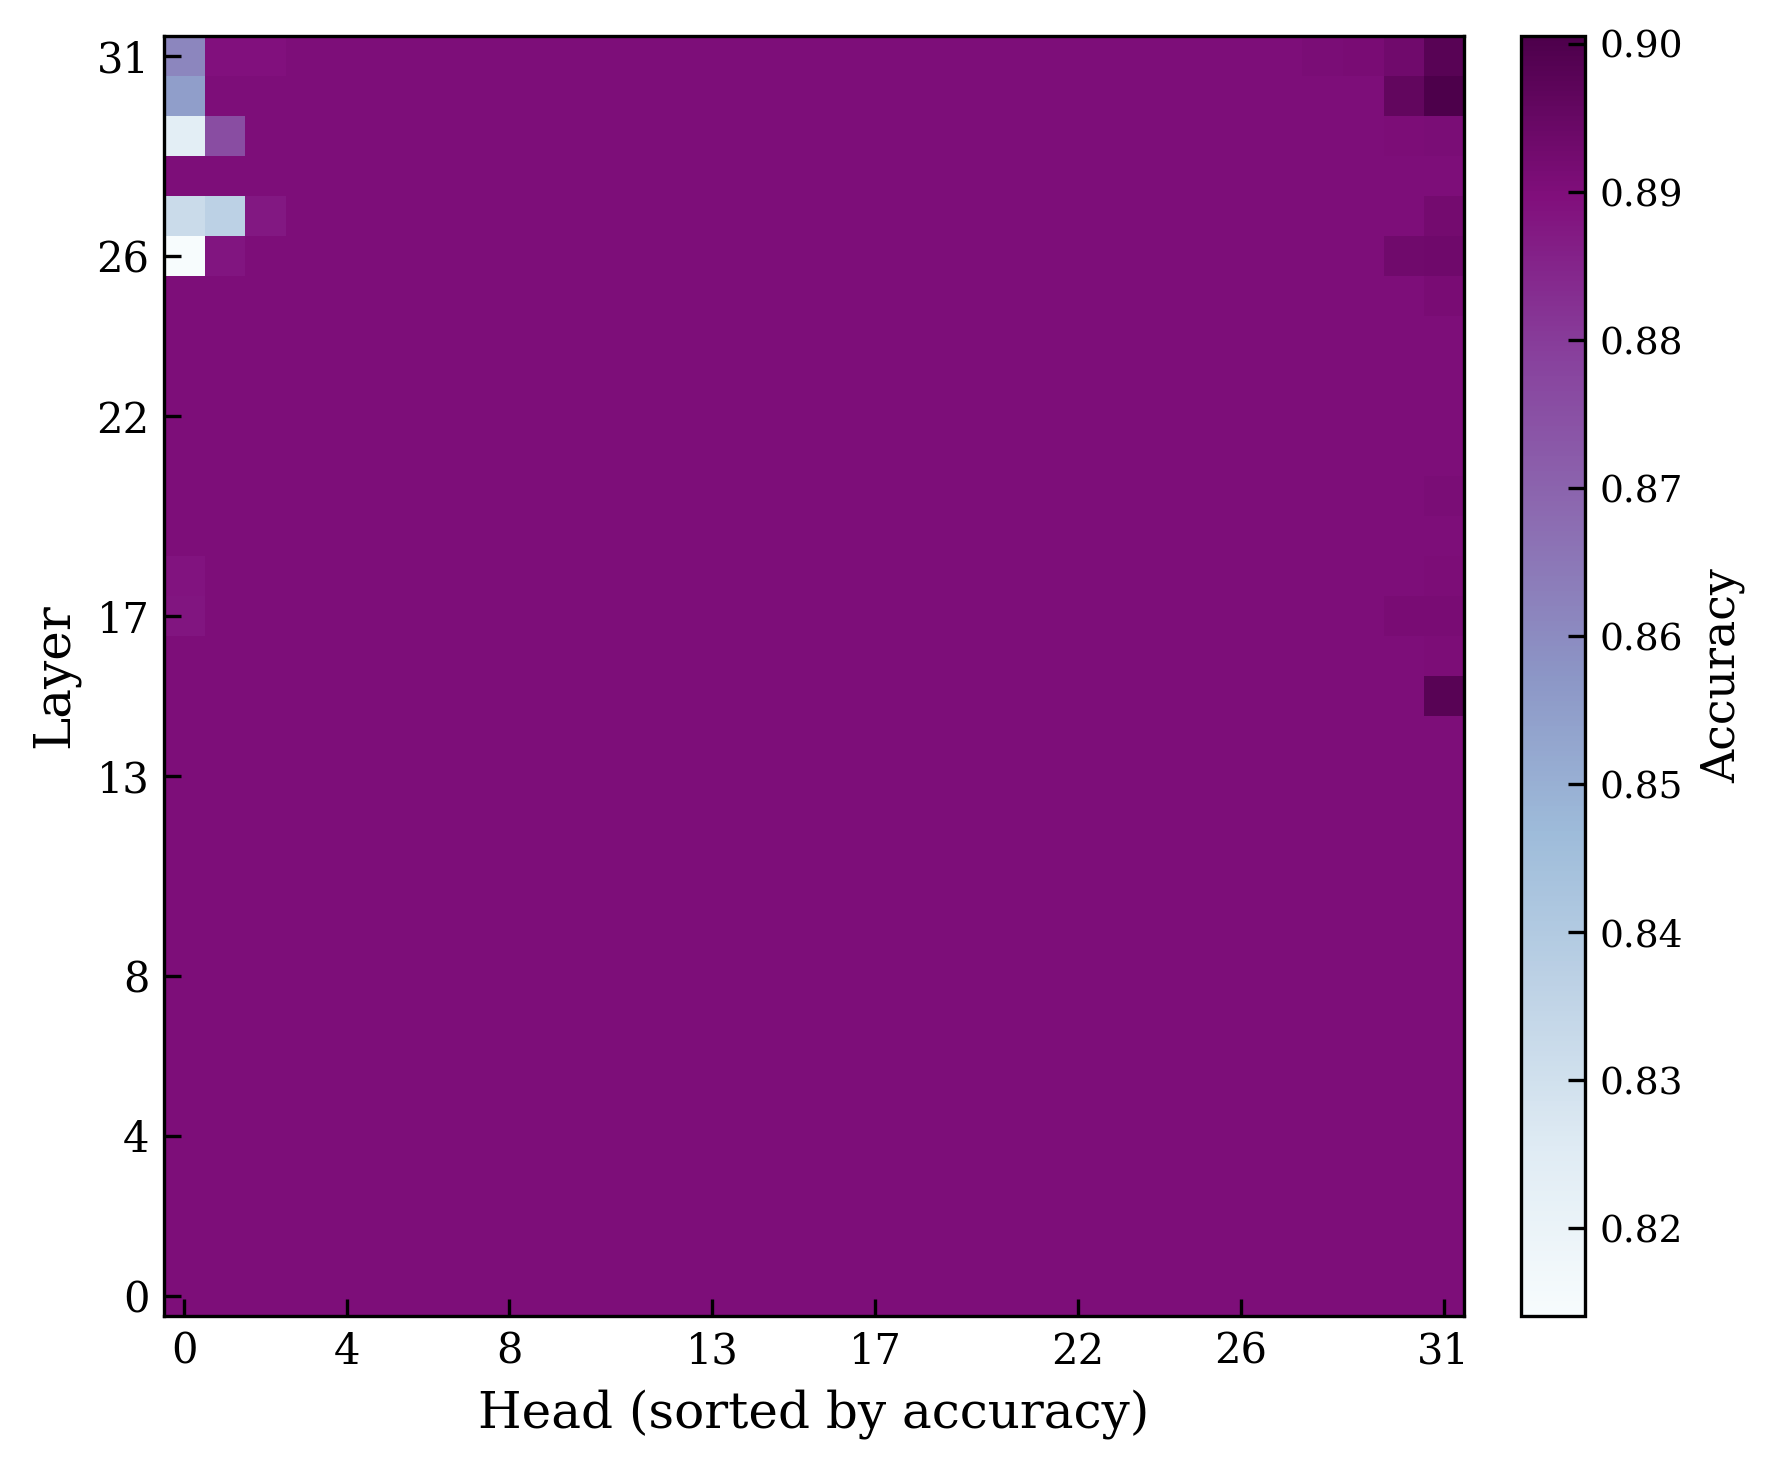

In [83]:
# ── Publication style (if not already set) ──
'''
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "figure.dpi": 150,
})
'''

predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)

fig, ax = plt.subplots(figsize=(6, 5))

pos = ax.imshow(predictor_accuracy_sorted, cmap="BuPu", aspect="auto", origin="lower")

ax.set_ylabel("Layer")
ax.set_xlabel("Head (sorted by accuracy)")
#ax.set_title("Attention Head Accuracies")

# Move x-axis labels/ticks to bottom (matshow puts them on top)
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")

# Reduce tick clutter
n_layers, n_heads = predictor_accuracy_sorted.shape
ax.set_xticks(np.linspace(0, n_heads - 1, min(n_heads, 8)).astype(int))
ax.set_yticks(np.linspace(0, n_layers - 1, min(n_layers, 8)).astype(int))

# Colorbar
cbar = fig.colorbar(pos, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Accuracy", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()
#fig.savefig("../figures/probe.pdf", bbox_inches="tight", dpi=300)

In [84]:
from sklearn.metrics import roc_curve, auc

# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

accuracies = []
fprs = []
precisions = []
recalls = []
f1s = []
probs = []
test_labels = []
mean_fpr_grid = np.linspace(0, 1, 200)
fold_tprs = []
fold_aucs = []

folds = [f for f in grouped_kfold_split(extracted_df['title'].values)]

for fold, (train_idx, test_idx) in enumerate(folds):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_bool = np.asarray(y_pred).astype(bool)
    y_true = np.asarray(y_test).astype(bool)

    tp = int(((y_pred_bool == True) & (y_true == True)).sum())
    tn = int(((y_pred_bool == False) & (y_true == False)).sum())
    fp = int(((y_pred_bool == True) & (y_true == False)).sum())
    fn = int(((y_pred_bool == False) & (y_true == True)).sum())

    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else float('nan')
    fold_denom = fp + tn
    fpr = (fp / fold_denom) if fold_denom > 0 else float('nan')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    fprs.append(fpr)

    # Per-fold reporting
    n_pos = int(y_true.sum())
    n_neg = int((~y_true).sum())
    print(f"  Fold {fold}: n={len(y_test)} (pos={n_pos}, neg={n_neg}) | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}")

    # Calibration
    y_prob = model.predict_proba(X_test)[:, 1]
    probs.append(y_prob)
    test_labels.append(y_test)

    # AUROC
    fpr_fold, tpr_fold, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_fold, tpr_fold)
    fold_aucs.append(roc_auc)

    # Interpolate TPR onto common FPR grid
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    fold_tprs.append(interp_tpr)

probs = np.concatenate(probs)
test_labels = np.concatenate(test_labels)

fold_tprs = np.array(fold_tprs)
mean_tpr = fold_tprs.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = fold_tprs.std(axis=0)
mean_auc = np.mean(fold_aucs)
std_auc = np.std(fold_aucs)

print()
print(f"Attn head model avg. accuracy:   {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Attn head model avg. precision:  {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Attn head model avg. recall:     {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Attn head model avg. F1:         {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Attn head model avg. FPR:        {np.mean(fprs):.4f} ± {np.std(fprs):.4f}")

  Fold 0: n=371 (pos=331, neg=40) | Acc=0.9272  Prec=0.9246  Rec=1.0000  F1=0.9608  FPR=0.6750
  Fold 1: n=175 (pos=159, neg=16) | Acc=0.9086  Prec=0.9086  Rec=1.0000  F1=0.9521  FPR=1.0000
  Fold 2: n=239 (pos=222, neg=17) | Acc=0.9791  Prec=0.9822  Rec=0.9955  F1=0.9888  FPR=0.2353
  Fold 3: n=267 (pos=230, neg=37) | Acc=0.8464  Prec=0.8706  Rec=0.9652  F1=0.9155  FPR=0.8919
  Fold 4: n=384 (pos=330, neg=54) | Acc=0.8594  Prec=0.8594  Rec=1.0000  F1=0.9244  FPR=1.0000

Attn head model avg. accuracy:   0.9041 ± 0.0480
Attn head model avg. precision:  0.9091 ± 0.0437
Attn head model avg. recall:     0.9921 ± 0.0136
Attn head model avg. F1:         0.9483 ± 0.0263
Attn head model avg. FPR:        0.7604 ± 0.2881


In [ ]:
folds[0]

In [ ]:
matching_recall * 0.9295

In [53]:
from scholarlm.measurementlm import NumpyEncoder

extracted_df['confidence'] = probs
extracted_df_dict = extracted_df.to_dict(orient = 'records')
outfile = "../data/experiments/2026_03_04/pond_judged_combined_scores.json"
with open(outfile, 'w') as f:
    json.dump(extracted_df_dict, f, indent=4, ensure_ascii=False, cls=NumpyEncoder)
#extracted_df.to_csv("../data/experiments/2026_03_04/pond_judged_combined_scores.csv")

In [35]:
matching_recall * 0.9295

0.6531032258064516

### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

In [85]:
def plot_calibration(
    ax,
    calibrations,          # list of dicts: {centers, means, ses, counts, color, label}
    title="",
    xlabel="Predicted Probability",
    ylabel="Observed Frequency",
    annotate=True,
    annotation_fontsize=7.5,
    legend_loc="upper left",
    xlim=(-0.03, 1.03),
    ylim=(-0.03, 1.03),
):
    """
    Plot one or more calibration curves on a single Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    calibrations : list of dict
        Each dict must contain:
            centers : array-like – bin midpoints
            means   : array-like – observed positive rate per bin
            ses     : array-like – standard error per bin
            counts  : array-like – sample count per bin
            color   : str        – line / fill color
            label   : str        – legend label
    title, xlabel, ylabel : str
    annotate : bool
        If True, label each point with its bin count.
    annotation_fontsize : float
    legend_loc : str
    xlim, ylim : tuple
    """
    # ── Diagonal reference ──
    ax.plot(
        [0, 1], [0, 1],
        ls="--", color=COLORS["diag"], lw=0.8,
        label="Perfectly calibrated", zorder=1,
    )

    # ── Each calibration curve ──
    for cal in calibrations:
        centers = cal["centers"]
        means   = cal["means"]
        ses     = cal["ses"]
        counts  = cal["counts"]
        color   = cal["color"]
        label   = cal["label"]

        # Shaded ±1 SE band
        ax.fill_between(
            centers, means - ses, means + ses,
            alpha=0.18, color=color, edgecolor="none", zorder=2,
        )
        # Line + markers
        ax.plot(
            centers, means, "o-",
            color=color, ms=4, lw=1.4, label=label, zorder=3,
        )
        # Bin-count annotations
        if annotate:
            for x, y, n in zip(centers, means, counts):
                txt = ax.annotate(
                    f"$n$={n}", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=annotation_fontsize,
                    color="dimgray",
                )
                txt.set_path_effects([
                    mpl.patheffects.withStroke(linewidth=2.5, foreground="white"),
                ])

    # ── Axes formatting ──
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    # Lighten spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.4")
    ax.tick_params(width=0.6, color="0.4", labelsize=8)

    ax.legend(frameon=False, loc=legend_loc, fontsize=8)

In [86]:
cal_llama = compute_calibration(probs, test_labels)
best_t = fit_temperature_from_probs(probs, 1 - probs, test_labels)
probs_temp, probs_false_temp = apply_temperature_from_probs(probs, 1 - probs, best_t)
cal_llama_temp = compute_calibration(probs_temp, test_labels)

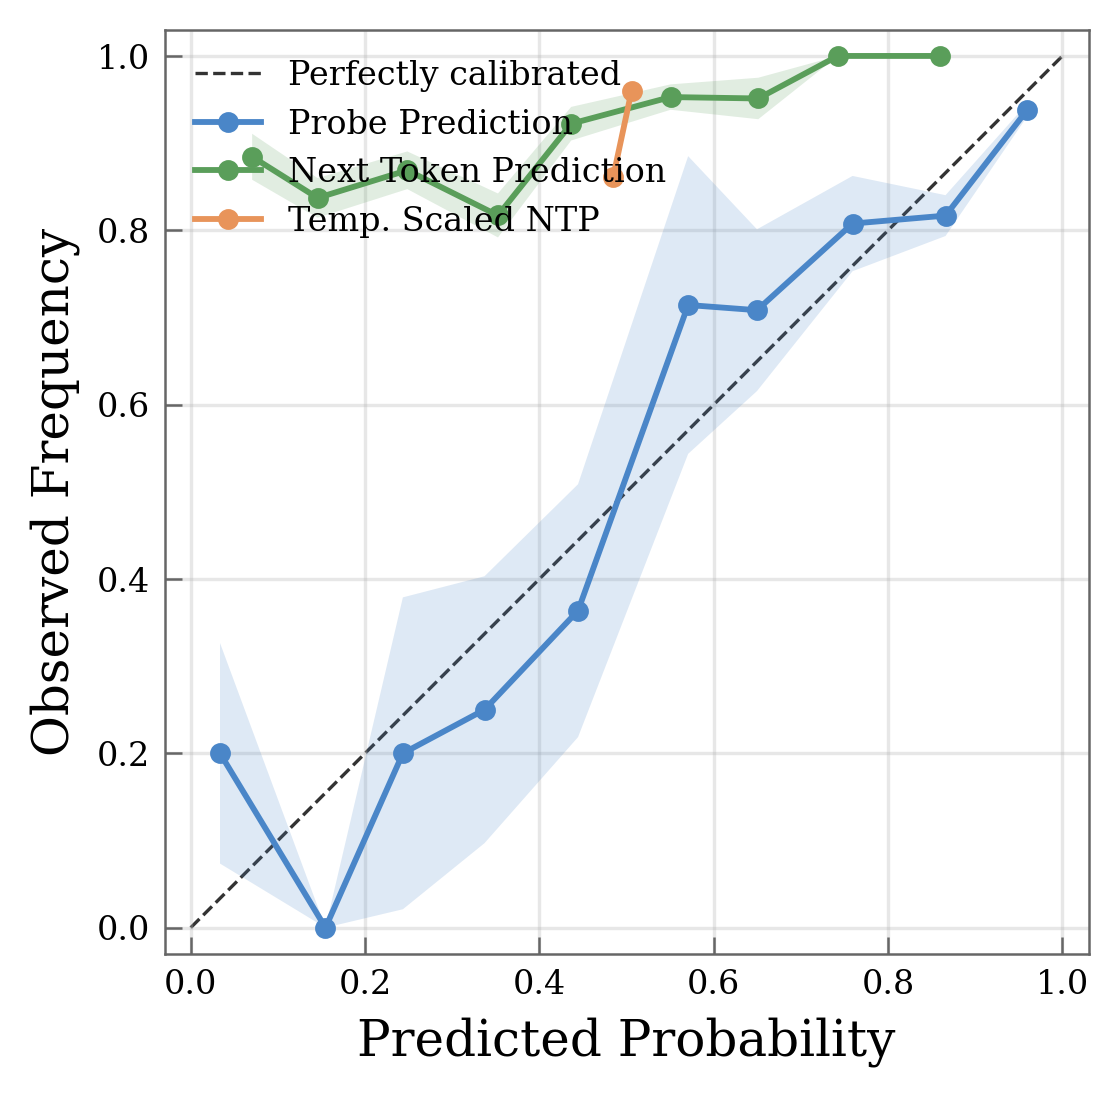

In [87]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_calibration(ax, [
    {**cal_llama, "color": "#4A86C8", "label": "Probe Prediction"},
    #{**cal_llama_temp, "color": "#ff9999", "label": "Temp. Scaled Probe Prediction"},
    {**cal_llama_baseline,   "color": "#5A9E5A", "label": "Next Token Prediction"},
    {**cal_llama_baseline_temp,   "color": "#E8945A", "label": "Temp. Scaled NTP"},
], title=None, annotate=False)
ax.grid(True, alpha=0.3)
#fig.savefig("../figures/calibration.pdf", bbox_inches="tight", dpi=300)

In [54]:
np.linspace(0.5, 1.0, 11)

array([0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

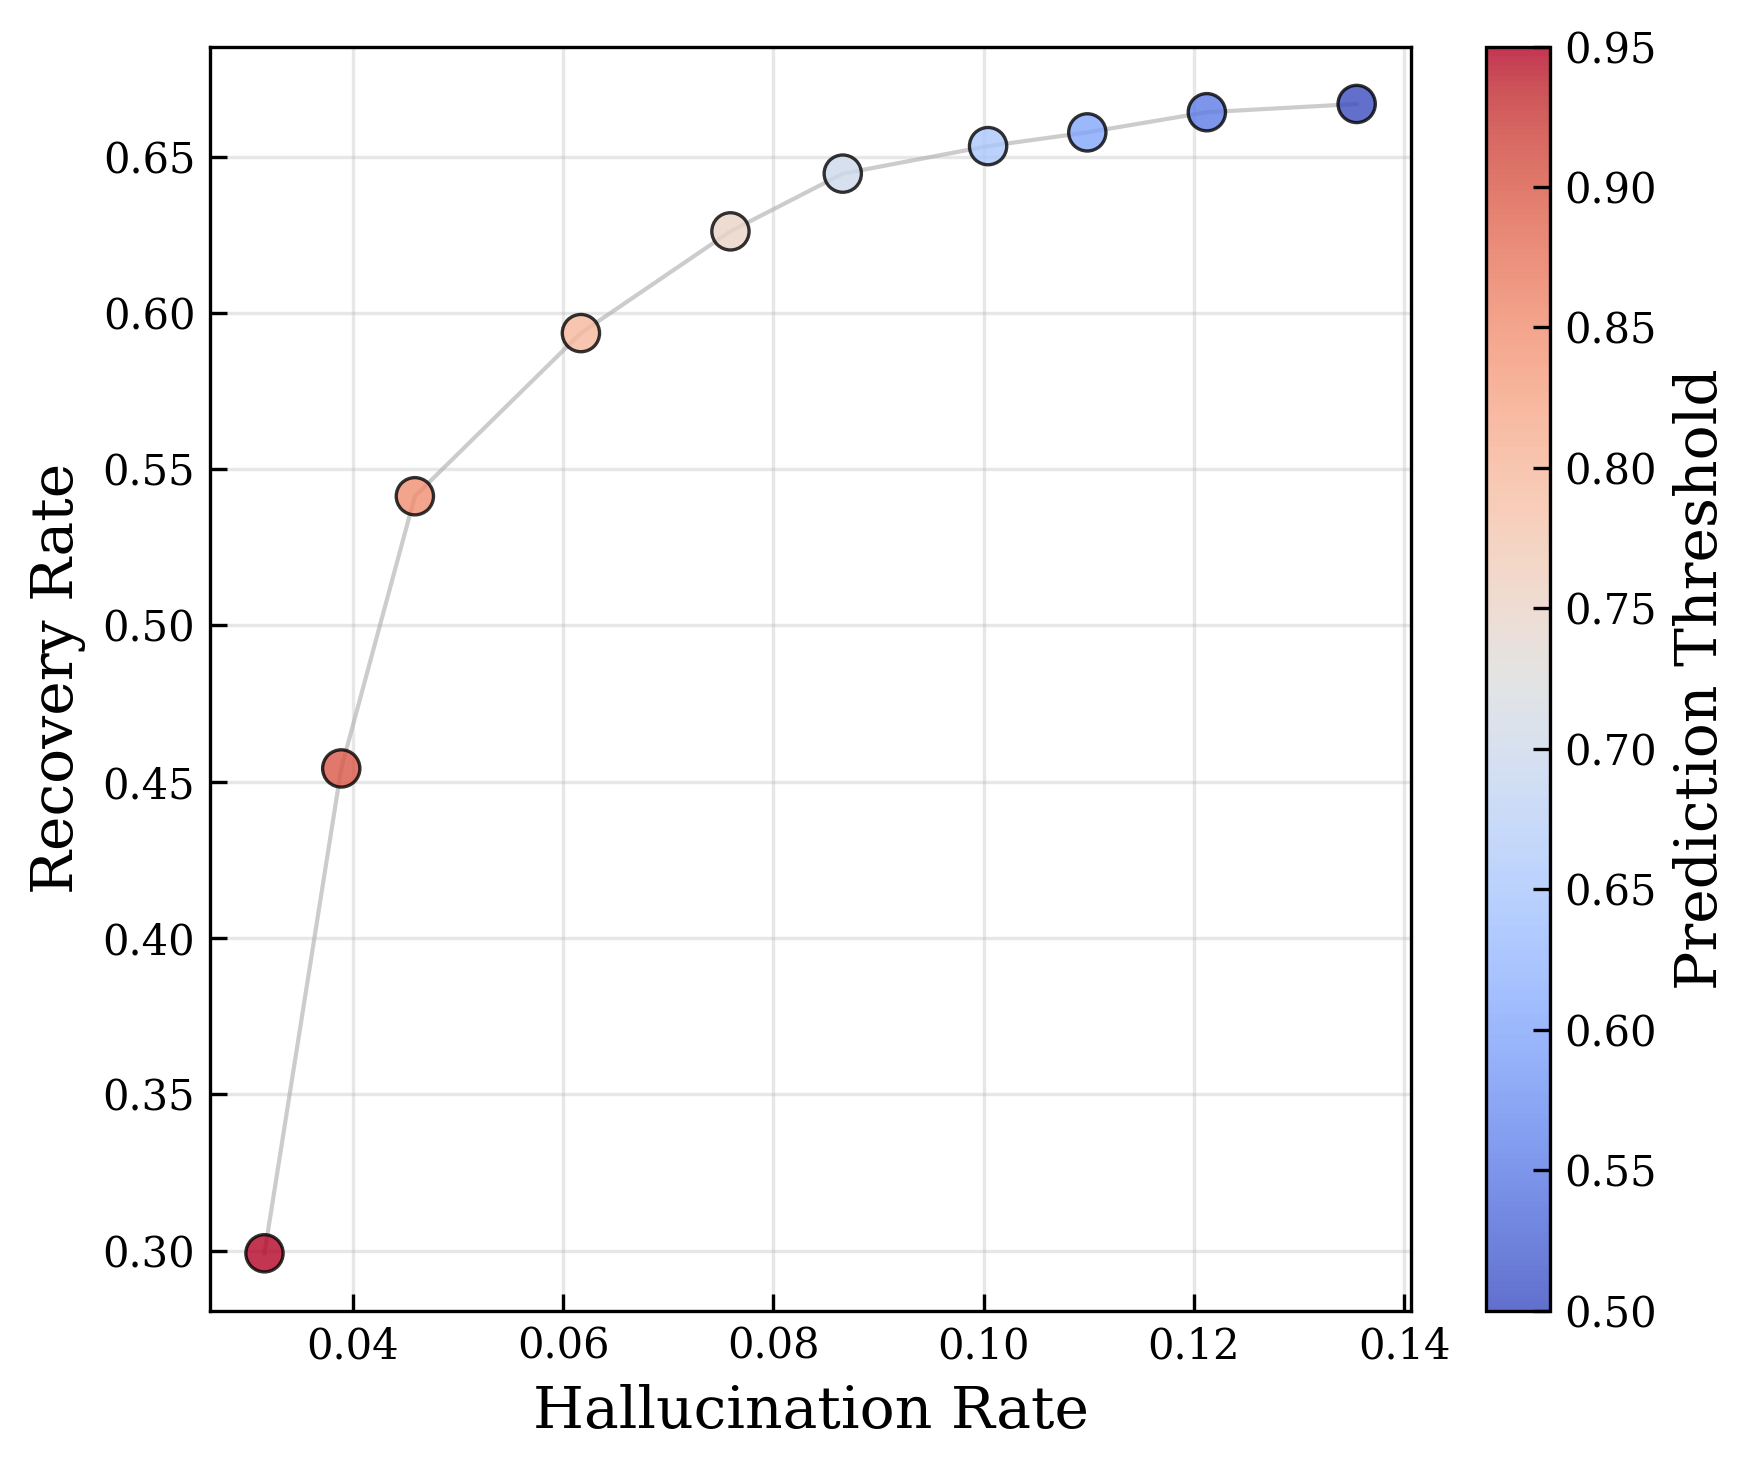

In [67]:
# Evaluate performance across different thresholds
thresholds = np.linspace(0.5, 1.0, 11)  # 0.5, 0.6, 0.7, ..., 1.0

recovery_rates = []
hallucination_rates = []

# Get full predictions for all samples using fold predictions
probs_all = np.full(len(extracted_df), np.nan)

for fold, (train_idx, test_idx) in enumerate(grouped_kfold_split(extracted_df['title'].values)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    probs_all[test_idx] = y_prob

# Get matching_status and validation labels
matching_status = extracted_df['matching_status'].to_numpy().astype(bool)
validation_labels = extracted_df['validation'].to_numpy().astype(bool)

for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred_thresh = (probs_all >= threshold).astype(bool)
    n_pred = y_pred_thresh.sum()
    
    # Recovery rate: % of matched samples predicted as True
    n_matched = matching_status.sum()
    if n_matched > 0:
        matched_and_predicted = (matching_status & y_pred_thresh).sum()
        recovery_rate = matched_and_predicted / n_matched
    else:
        recovery_rate = np.nan
    
    # Hallucination rate: % predicted positive which are incorrect
    n_pred = y_pred_thresh.sum()
    if n_pred > 0:
        not_validated_and_predicted = ((~validation_labels) & y_pred_thresh).sum()
        hallucination_rate = not_validated_and_predicted / n_pred
    else:
        hallucination_rate = np.nan
    
    recovery_rates.append(recovery_rate)
    hallucination_rates.append(hallucination_rate)

recovery_rates = np.array(recovery_rates) * matching_recall
hallucination_rates = np.array(hallucination_rates)

# Create line plot with color gradient
fig, ax = plt.subplots(figsize=(6, 5))

# Plot line connecting points
scatter = ax.scatter(
    hallucination_rates, recovery_rates,
    c=thresholds, cmap='coolwarm', s=80, alpha=0.8, 
    edgecolors='black', linewidth=0.8, zorder=3
)

# Connect points with line
ax.plot(
    hallucination_rates, recovery_rates,
    color='gray', alpha=0.4, linewidth=1, zorder=1
)

ax.set_xlabel('Hallucination Rate', fontsize=14)
ax.set_ylabel('Recovery Rate', fontsize=14)
#ax.set_xlim(-0.05, 1.05)
#ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
#ax.set_aspect('equal')

# Add colorbar
cbar = fig.colorbar(scatter, ax=ax, label='Prediction Threshold')
cbar.set_label('Prediction Threshold', fontsize=14)

plt.tight_layout()
fig.savefig("../figures/prediction_threshold.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [60]:
hallucination_rates

array([0.13547696, 0.12122548, 0.10985533, 0.10041841, 0.08659694,
       0.07591354, 0.06169014, 0.04589528, 0.03889334, 0.03159252,
              nan])

In [61]:
recovery_rates

array([0.66686217, 0.66422287, 0.65777126, 0.65337243, 0.64457478,
       0.62609971, 0.59354839, 0.54134897, 0.4542522 , 0.29912023,
       0.        ])